# LAB06


## BLOCCO 1

### ATTIVITÀ 1.1

In [1]:
import numpy as np
def neurone_binario(x1, x2, w1, w2, b):
  z = w1 * x1 + w2 * x2 + b
  return 1 if z >= 0 else 0
# Tutte le possibili coppie di ingressi
X = [(0,0), (0,1), (1,0), (1,1)]

# AND
print("AND")
for x1, x2 in X:
    print(x1, x2, "->", neurone_binario(x1, x2, 1, 1, -1.5))

# OR
print("\nOR")
for x1, x2 in X:
    print(x1, x2, "->", neurone_binario(x1, x2, 1, 1, -0.5))

# NAND
print("\nNAND")
for x1, x2 in X:
    print(x1, x2, "->", neurone_binario(x1, x2, -1, -1, 1.5))

AND
0 0 -> 0
0 1 -> 0
1 0 -> 0
1 1 -> 1

OR
0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 1

NAND
0 0 -> 1
0 1 -> 1
1 0 -> 1
1 1 -> 0


4. - Il bias sposta la soglia di attivazione del neurone. Un bias molto negativo rende il neurone difficile da attivare (serve una somma alta degli input), mentre un bias positivo lo rende facile da attivare anche con input bassi.
    - Perché gli input sono solo 0 o 1, e la funzione a gradino divide nettamente i casi in due gruppi. Scegliendo pesi e bias appropriati, il neurone separa esattamente i casi "vero" dai casi "falso", replicando il comportamento delle porte logiche.

### ATTIVITÀ 1.2

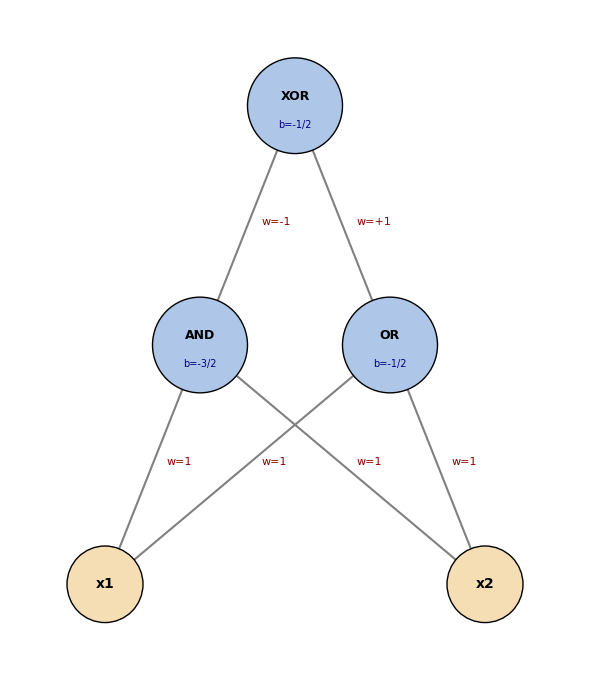

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(6, 7))
ax.set_xlim(0, 6)
ax.set_ylim(0, 7)
ax.axis('off')

nodi = {
    'x1':  (1, 1),
    'x2':  (5, 1),
    'AND': (2, 3.5),
    'OR':  (4, 3.5),
    'XOR': (3, 6),
}

connessioni = [
    ('x1', 'AND', 'w=1'),
    ('x2', 'AND', 'w=1'),
    ('x1', 'OR',  'w=1'),
    ('x2', 'OR',  'w=1'),
    ('AND', 'XOR', 'w=-1'),
    ('OR',  'XOR', 'w=+1'),
]

for da, a, peso in connessioni:
    x1, y1 = nodi[da]
    x2, y2 = nodi[a]
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.5))
    mx, my = (x1+x2)/2, (y1+y2)/2
    ax.text(mx + 0.15, my, peso, fontsize=8, color='darkred')

for nome, (x, y) in nodi.items():
    if nome in ('x1', 'x2'):
        circle = plt.Circle((x, y), 0.4, color='#f5deb3', ec='black', zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, nome, ha='center', va='center', fontsize=10, fontweight='bold')
    else:
        bias = {'AND': 'b=-3/2', 'OR': 'b=-1/2', 'XOR': 'b=-1/2'}
        circle = plt.Circle((x, y), 0.5, color='#aec6e8', ec='black', zorder=3)
        ax.add_patch(circle)
        ax.text(x, y + 0.1, nome, ha='center', va='center', fontsize=9, fontweight='bold')
        ax.text(x, y - 0.2, bias[nome], ha='center', va='center', fontsize=7, color='navy')

plt.tight_layout()
plt.show()

Gli input x1 e x2 entrano contemporaneamente in due neuroni nascosti:
- il neurone AND $(b = -\frac{3}{2})$ si attiva solo se entrambi gli input sono 1
- il neurone OR $(b = -\frac{1}{2})$ si attiva se almeno uno degli input è 1

Le uscite dei due neuroni arrivano al neurone finale con pesi opposti ($w=-1$ per AND, $w=+1$ per OR),
che calcola OR - AND. Questo dà 1 solo quando i due input sono diversi tra loro,che è esattamente la definizione di XOR.

## BLOCCO 2 \- TLU / perceptron come classificatore lineare

### Attività 2\.1 – Dati 2D linearmente separabili

Genera un piccolo dataset 2D con due classi ben separate:

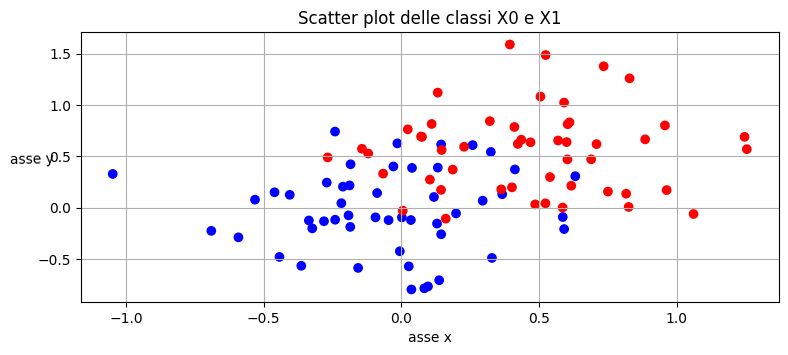

In [3]:
# codice per dimostrare che il perceptron NON converge su dati NON linearmente separabili
# questo si dimostra tramite l'avvicinamento dei dati delle due classi

from matplotlib.typing import ColorType
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 50
# modifica gli np.array e vedi che succede avvicinando i punti
X0 = np.random.randn(n, 2) * 0.4 + np.array([0, 0]) # classe 0
X1 = np.random.randn(n, 2) * 0.4 + np.array([0.5, 0.5]) # classe 1
X = np.vstack([X0, X1])
y = np.array([0]*n + [1]*n)

plt.figure(figsize=(9, 3.5))
plt.scatter(X[:,0],X[:,1], c=y, cmap='bwr')
plt.title("Scatter plot delle classi X0 e X1")
plt.xlabel("asse x")
plt.ylabel("asse y", rotation=1)
plt.grid()
plt.show()

Se avvicino i valori delle due classi, modificando una delle due ordinate all'origine, si può notare una sovrapposizione parziale tra i punti delle due classi\. Di conseguenza, la retta di decisione non separa correttamente le due classi\. 

Il perceptron non riesce ad azzerare gli errori, aggiornando continuando ad aggiornare i pesi e e facendo ruotare/traslare la retta all'infinito e restituirà la retta dell'ultima iterazione\.

In [4]:
from matplotlib.typing import ColorType
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 50
# modifica gli np.array e vedi che succede avvicinando i punti
X0 = np.random.randn(n, 2) * 0.4 + np.array([0, 0]) # classe 0
X1 = np.random.randn(n, 2) * 0.4 + np.array([2, 2]) # classe 1
X = np.vstack([X0, X1])
y = np.array([0]*n + [1]*n)

1\. Fai uno scatter plot dei punti, usando un colore diverso per ciascuna classe\.

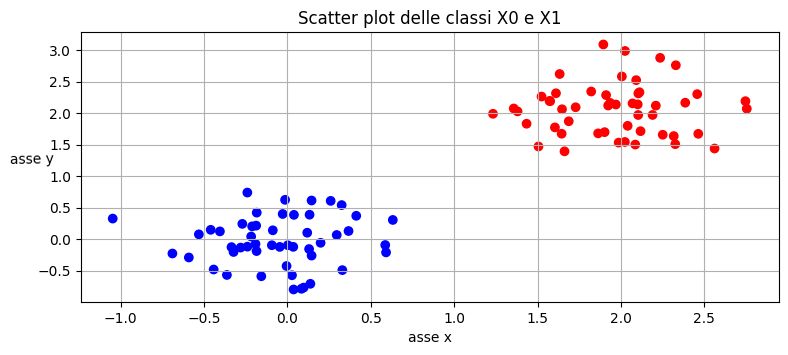

In [5]:
plt.figure(figsize=(9, 3.5))
plt.scatter(X[:,0],X[:,1], c=y, cmap='bwr')
plt.title("Scatter plot delle classi X0 e X1")
plt.xlabel("asse x")
plt.ylabel("asse y", rotation=1)
plt.grid()
plt.show()

2\. Descrivi a parole:

- Perché pensi che queste due classi siano linearmente separabili?

Queste due classi X0 e X1 sono linearmente separabili perché, osservando il grafico, si può notare la possibilità di separare le due classi attraverso un'unica linea retta; anche se vi sono infiniti iperpiani che possono separ
are le due nuvole di punti senza commettere errori\.


### Attività 2\.2 – Perceptron “from scratch” e con Scikit\-Learn

**Opzione A:** implementare il training del perceptron a mano, con la regola:
$w \leftarrow w + \eta(y - \hat{y})x$, $b \leftarrow b + \eta(y - \hat{y})$
dove $\hat{y}$ è l'uscita del TLU sul singolo esempio.

Skeleton

In [6]:
# implementazione manuale
def tlu(X, w, b):
  z = X @ w + b
  return (z >= 0).astype(int)

def perceptron_train(X, y, eta=0.1, epochs=20):
  w = np.zeros(X.shape[1])
  b = 0.0
  for epoch in range(epochs):
    for xi, yi in zip(X, y):
      y_hat = tlu(xi.reshape(1, -1), w, b)[0]
      w += eta * (yi - y_hat) * xi
      b += eta * (yi - y_hat)
  return w, b

w,b = perceptron_train(X,y)
print(f"w = {w}\nb = {b}")

w = [0.0777405  0.13331414]
b = -0.2


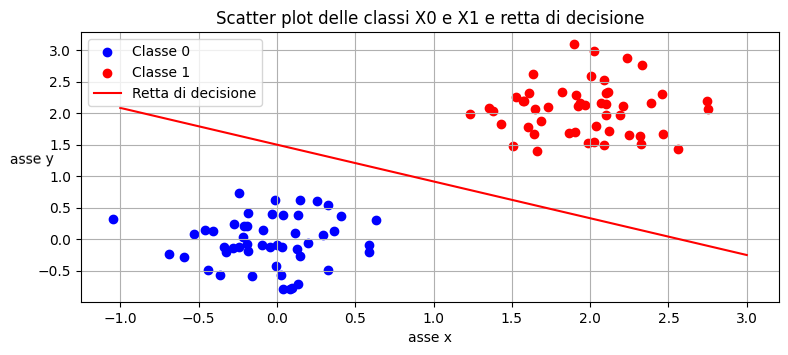

In [7]:
# equazione w1 * x1 + w2 * x2 + b = 0
# risolta rispetto a x2 -> x2 = -(w1*x1+b)/w2
plt.figure(figsize=(9, 3.5))
plt.scatter(X0[:,0],X0[:,1], label="Classe 0", c='blue')
plt.scatter(X1[:,0],X1[:,1], label="Classe 1", c='red')

plt.title("Scatter plot delle classi X0 e X1 e retta di decisione")
plt.xlabel("asse x")
plt.ylabel("asse y", rotation=1)
plt.grid()

x1 = np.linspace(-1,3,100)
x2 = -(w[0]*x1+b)/w[1]
plt.plot(x1,x2,'-r', label="Retta di decisione")

plt.legend()
plt.show()

In [8]:
# implementazione tramite libreria
# se non definisco eta0 e max_iter e shuffle, w e b hanno risultati diversi perché le classi sono linearmente separabili
from sklearn.linear_model import Perceptron
perc = Perceptron(random_state=42, eta0=0.1,max_iter=20)
perc.fit(X, y)
w = perc.coef_[0]
b = perc.intercept_[0]

print(f"w = {w}\nb = {b}")


w = [0.20093513 0.13835759]
b = -0.30000000000000004


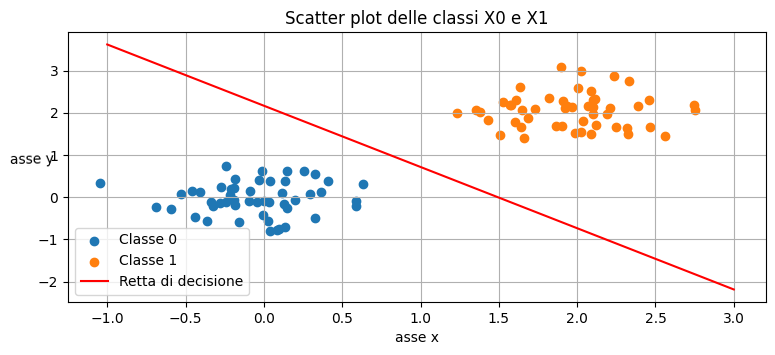

In [9]:
plt.figure(figsize=(9, 3.5))
plt.scatter(X0[:,0],X0[:,1], label="Classe 0")
plt.scatter(X1[:,0],X1[:,1], label="Classe 1")

plt.title("Scatter plot delle classi X0 e X1")
plt.xlabel("asse x")
plt.ylabel("asse y", rotation=1)
plt.grid()

x1 = np.linspace(-1,3,100)
x2 = -(w[0]*x1+b)/w[1]
plt.plot(x1,x2,'-r', label="Retta di decisione")

plt.legend()
plt.show()

**Come si muove la retta di decisione durante l'addestramento (se hai implementato la versione manuale)?**
Durante l'addestramento, la retta di decisione si muove se e solo se il modello commette un errore di classificazione. L'aggiornamento del perceptron avviene sui pesi (**w**) che rappresentano la pendenza della retta e causandone una rotazione, e sul bias (**b**) che rappresenta l'intercetta all'origine causandone una traslazione.

**Che ruolo ha il learning rate _eta_?**
Il learning rate _eta_ è un iperparametro che controlla la dimensione di ogni passo di ottimizzazione nello spazio dei parametri. Se il valore del learning rate è troppo piccolo, allora il modello è lento; se è troppo grande allora il modello potrebbe essere instabile.

**Perché il perceptron converge su questo dataset?**
In questo dataset, il perceptron converge perché le istanze del training sono linearmente separabili. Ciò è definito nel teorema della convergenza del perceptron.

## BLOCCO 3

### Attività 3\.1 \- XOR e perceptron

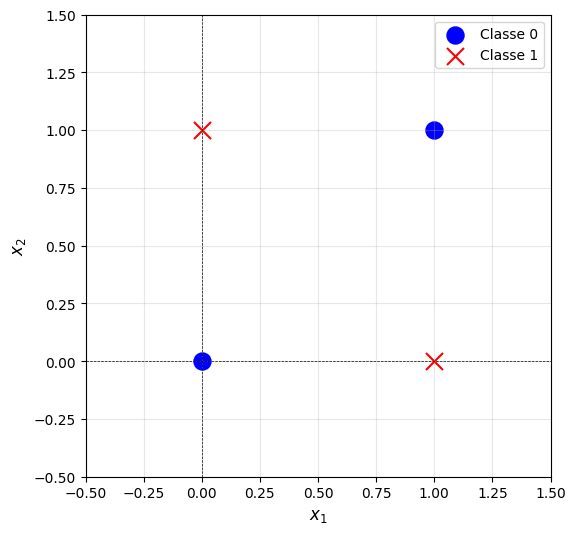

In [10]:
import numpy as np
import matplotlib.pyplot as plt

X_xor = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=int)

plt.figure(figsize=(6, 6))

plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], 
            color='blue', marker='o', s=150, label='Classe 0')

plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], 
            color='red', marker='x', s=150, label='Classe 1')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
perc_xor = Perceptron(random_state=42, max_iter=1000)
perc_xor.fit(X_xor, y_xor)
y_pred = perc_xor.predict(X_xor)
print("Accuracy perceptron su XOR:", accuracy_score(y_xor, y_pred))
print("Predizioni:", y_pred)

Accuracy perceptron su XOR: 0.5
Predizioni: [0 0 0 0]


**Osservando il grafico, perchè non esiste una retta che separa perfettamente le due classi XOR?**
Un perceptron definisce esclusivamente un confine di decisione lineare nello spazio degli input. Poiché un singolo perceptron può apprendere solamente confini lineari, non esiste una retta che separa perfettamente le due classi XOR. Questo significa che il dataset XOR è affetto da inseparabilità lineare.

**Il perceptron riesce a raggiungere accuratezza 1.0 su XOR? Perché?**
Il perceptron non riesce a raggiungere un'accuratezza di 1.0 ma si ferma al 50% (0.5). Il motivo risiede nei limiti dei perceptron: essendo modelli lineari, non hanno la capacità di risolvere problemi con inseparabilità lineare. Per raggiungere un'accuratezza di 1.0 su XOR è necessario un Multi Layer Perceptron (MLP). Un MLP diventa potente e capace di rappresentare funzioni molto più complesse rispetto a un perceptron grazie alla combinazione di strati nascosti (hidden layers) e, soprattutto, di unità di attivazione non lineari.

### Attività 3\.2 \- MLPClassifier su XOR

In [12]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(4,),
activation="tanh",
solver="sgd",
learning_rate_init=0.1,
max_iter=10000,
random_state=42)
mlp.fit(X_xor, y_xor)
y_pred_mlp = mlp.predict(X_xor)
print("Accuracy MLP su XOR:", accuracy_score(y_xor, y_pred_mlp))
print("Predizioni MLP:", y_pred_mlp)

Accuracy MLP su XOR: 1.0
Predizioni MLP: [0 1 1 0]


1. **Verificare che l'MLP riesce a raggiungere accuratezza 1.0 sul training set XOR.**
A differenza del singolo perceptron, la presenza dello strato nascosto (hidden layer) e della funzione di attivazione non lineare (tanh) ha permesso alla rete di imparare due confini decisionali distinti che si combinano, isolando correttamente i punti nello spazio. Quindi, l'MLP riesce a raggiungere 1.0 di accuratezza sul training set XOR.

2. **Provare a cambiare i parametri e osservare l'effetto su accuratezza e confini decisionali.**

In [13]:
configs = [
    # 1. cambiare i neuroni nascosti
    {"hidden_layer_sizes": (2,), "activation": "tanh", "learning_rate_init": 0.1},
    {"hidden_layer_sizes": (3,), "activation": "tanh", "learning_rate_init": 0.1},
    
    # 2. cambiare la funzione di attivazione
    {"hidden_layer_sizes": (4,), "activation": "relu", "learning_rate_init": 0.1},
    
    # 3. cambiare il learning rate
    {"hidden_layer_sizes": (4,), "activation": "tanh", "learning_rate_init": 0.01},
    {"hidden_layer_sizes": (4,), "activation": "tanh", "learning_rate_init": 0.5},
]

for i, config in enumerate(configs):
    m = MLPClassifier(**config, solver="sgd", max_iter=10000, random_state=42)
    m.fit(X_xor, y_xor)
    acc = accuracy_score(y_xor, m.predict(X_xor))
    print(f"Test {i+1} | Configurazione: {config}")
    print(f"   -> Accuracy: {acc}\n")

Test 1 | Configurazione: {'hidden_layer_sizes': (2,), 'activation': 'tanh', 'learning_rate_init': 0.1}
   -> Accuracy: 0.5

Test 2 | Configurazione: {'hidden_layer_sizes': (3,), 'activation': 'tanh', 'learning_rate_init': 0.1}
   -> Accuracy: 1.0

Test 3 | Configurazione: {'hidden_layer_sizes': (4,), 'activation': 'relu', 'learning_rate_init': 0.1}
   -> Accuracy: 1.0

Test 4 | Configurazione: {'hidden_layer_sizes': (4,), 'activation': 'tanh', 'learning_rate_init': 0.01}
   -> Accuracy: 1.0

Test 5 | Configurazione: {'hidden_layer_sizes': (4,), 'activation': 'tanh', 'learning_rate_init': 0.5}
   -> Accuracy: 1.0



Cambio numero di neuroni nascosti:

- Cambiando i neuroni nascosti a 3 o 4, la rete raggiunge un'accuratezza pari a 1\.0\. Questo dimostra che il modello possiede una capacità rappresentativa adeguata per apprendere in modo stabile i confini decisionali non lineari richiesti dal problema XOR\.

- Al contrario, riducendo lo strato a soli 2 neuroni, le prestazioni calano di molto\. Un numero troppo basso di neuroni porta a fenomeni di underfitting, poiché il modello "manca di capacità rappresentativa"\. Il Gradient Descent deve esplorare una superficie di errore \(loss surface\) complessa e non convessa\. Avere un numero minimo di parametri \(solo 2 neuroni\) rende questa superficie più difficile da navigare, aumentando notevolmente il rischio che l'ottimizzatore rimanga intrappolato in un minimo locale

Cambio funzione di attivazione:

- Cambiando la funzione in "relu", l'accuratezza rimane 1\.0\. Questo succede perché entrambe le funzioni soddisfano il requisito principale: introdurre una non\-linearità necessaria per spezzare l'inseparabilità lineare\.

Cambio del learning rate

- Scendendo a 0\.01, l'accuratezza arriva sempre a 1\.0, ma all'interno del processo si nota che la rete impiega più iterazioni per addestrarsi\. Il learning rate controlla la dimensione dei passi del Gradient Descent nello spazio dei parametri: un passo troppo piccolo rende l'addestramento molto lento, un passo ottimale invece, lo velocizza senza renderlo instabile\.

3\. Rispondere alle domande:

- Perché un MLP con uno strato nascosto riesce a risolvere XOR mentre il perceptron no?

Un singolo perceptron può apprendere esclusivamente confini di decisione lineari, il che rende geometricamente impossibile separare le classi incrociate del dataset XOR\. Un Multi Layer Perceptron \(MLP\) supera questo limite grazie all'introduzione di uno strato nascosto che permette alla rete di costruire rappresentazioni intermedie e più utili dei dati\.

- Che ruolo ha la funzione di attivazione non lineare in questo esempio?

La funzione di attivazione non lineare è necessaria per permettere all'MLP di rappresentare funzioni ricche e confini decisionali complessi\. Senza di essa, se ogni strato fosse puramente lineare, l'intera rete multistrato collasserebbe matematicamente in un'unica trasformazione lineare, annullando del tutto il vantaggio di avere strati nascosti\. Inserendo funzioni differenziabili \(come tanh o relu\), si introduce la non\-linearità necessaria per superare i limiti del perceptron e risolvere problemi non linearmente separabili come l'XOR\.

- Cosa osservi cambiando il numero di neuroni nello strato nascosto?

Se si utilizzano solo 2 neuroni nascosti, il modello rischia di avere una capacità rappresentativa insufficiente \(underfitting\) o di rendere l'ottimizzazione instabile, rimanendo facilmente bloccato in minimi locali con accuratezza al 50%\. Aumentando i neuroni a 3 o 4, la rete ottiene sufficiente ridondanza e capacità per mappare la funzione in modo robusto\. Questa maggiore flessibilità agevola il lavoro dell'algoritmo di discesa del gradiente, permettendo al modello di convergere sempre e stabilmente verso un'accuratezza perfetta \(1\.0\)\.

Auto-valutazione finale
(a) neurone booleano per porte logiche
(b) perceptron/TLU come classificatore lineare
(c) MLP con strato nascosto

(a) Il neurone artificiale booleano per porte logiche è caratterizzato da input e output, determinati da numeri e ogni connessione di input è associata a un peso.
(b) Una TLU può essere utilizzata come classificatore lineare: calcola una funzione lineare dei suoi input. Se il suo risultato supera una soglia, restituisce la classe positiva; altrimenti, restituisce la classe negativa. Un perceptron è composto da più TLU organizzate in uno strato in cui ogni TLU è connessa a ogni input e può classificare istanze simultaneamente in 3 differenti classi binarie.
(c) Un MLP (MultiLayer Perceptron) ha uno strato di input, uno o più strati nascosti e uno strato di output. Gli strati nascosti permettono alla rete di costruire rappresentazioni intermedie dei dati. Con abbastanza unità nascoste non-lineari, un MLP può rappresentare funzioni molto più complesse rispetto ad un perceptron.

<img src="image-20260423-181640.png" width="" align="" />

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5700d1a3-48c2-45d9-a672-84b755126fc8' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>